# Kernel PCA

Kernel Principal Component Analysis (Kernel PCA) is a nonlinear extension of Principal Component Analysis (PCA).

Standard PCA is useful when the important structure in the data is approximately linear. However, many real-world datasets contain nonlinear structures such as circles, curves, spirals, and other complex shapes.

Kernel PCA addresses this problem by first mapping the original data into a higher-dimensional feature space and then performing PCA in that feature space.

The key idea is the **kernel trick**, which allows us to work with this higher-dimensional feature space without explicitly computing the transformation.

### Main idea

Standard PCA:

$$
\text{Original Space} \rightarrow \text{Linear PCA}
$$

Kernel PCA:

$$
\text{Original Space}
\rightarrow
\text{Feature Space}
\rightarrow
\text{Linear PCA}
$$

Kernel PCA is therefore capable of discovering nonlinear patterns that ordinary PCA cannot capture.

# 1. Why Do We Need Kernel PCA?

Principal Component Analysis tries to find directions of maximum variance in the data.

For datasets with approximately linear structure, PCA works very well.

However, consider a dataset where observations form a circular pattern.

A linear projection may not be able to separate or represent the important structure of the data.

### Example of nonlinear structure

Suppose the data contains two concentric circles.

The classes may be arranged like:

$$
\text{Inner Circle}
\quad \text{surrounded by} \quad
\text{Outer Circle}
$$

There is no single straight line that can properly separate the two structures.

Standard PCA searches for linear directions, so it may fail to represent this structure effectively.

Kernel PCA solves this by transforming the data into a higher-dimensional feature space where the nonlinear structure can become approximately linear.

### Core idea

Instead of trying to solve the nonlinear problem directly:

$$
\text{Nonlinear structure in original space}
$$

we transform the data:

$$
x \rightarrow \phi(x)
$$

and solve a linear PCA problem in the transformed space:

$$
\phi(X) \rightarrow \text{PCA}
$$

# 2. PCA vs Kernel PCA

## Standard PCA

Standard PCA assumes that the important directions in the data can be represented using linear combinations of the original features.

It finds directions:

$$
w_1, w_2, \ldots, w_k
$$

that capture maximum variance.

The projection of a sample $x$ onto a principal component is:

$$
z = w^T x
$$

This is a linear transformation.

---

## Kernel PCA

Kernel PCA first maps the input data into another feature space:

$$
x \rightarrow \phi(x)
$$

Then PCA is performed in that feature space.

The projection becomes:

$$
z = w^T \phi(x)
$$

The important problem is that $\phi(x)$ may have a very large or even infinite number of dimensions.

Kernel PCA avoids explicitly computing $\phi(x)$ by using a kernel function.

---

## Comparison

| PCA | Kernel PCA |
|---|---|
| Linear dimensionality reduction | Nonlinear dimensionality reduction |
| Works directly in original feature space | Works implicitly in a transformed feature space |
| Uses covariance matrix | Uses kernel matrix |
| Captures linear structure | Captures nonlinear structure |
| Computationally simpler | Usually more computationally expensive |
| Easier to interpret | Usually harder to interpret |

# 3. Intuition Behind Kernel PCA

The most important concept in Kernel PCA is the idea of a **feature space**.

Suppose our original data is:

$$
x \in \mathbb{R}^d
$$

We define a nonlinear transformation:

$$
\phi : \mathbb{R}^d \rightarrow \mathcal{F}
$$

where $\mathcal{F}$ is a higher-dimensional feature space.

Therefore:

$$
x \rightarrow \phi(x)
$$

The original data may have a nonlinear structure, but after transformation, that structure may become easier to represent using linear directions.

### Example

Suppose the original features are:

$$
x = (x_1, x_2)
$$

We could create additional nonlinear features such as:

$$
\phi(x) =
(x_1,\ x_2,\ x_1^2,\ x_2^2,\ x_1x_2)
$$

Now the data exists in a higher-dimensional space.

Performing ordinary PCA in this transformed space can capture nonlinear relationships from the original space.

The problem is that explicitly constructing $\phi(x)$ can be expensive.

This is where the kernel trick becomes useful.

# 4. The Kernel Trick

The kernel trick allows us to calculate relationships between transformed samples without explicitly computing the transformation.

Instead of calculating:

$$
\phi(x_i)^T \phi(x_j)
$$

we use a kernel function:

$$
K(x_i, x_j)
$$

such that:

$$
K(x_i, x_j)
=
\phi(x_i)^T \phi(x_j)
$$

Therefore, instead of explicitly computing the high-dimensional vectors $\phi(x_i)$ and $\phi(x_j)$, we calculate their similarity directly using the kernel function.

### Why is this useful?

The feature space can be extremely large.

For example:

$$
x \in \mathbb{R}^{10}
$$

might be mapped into a feature space containing hundreds or thousands of dimensions.

Some kernels even correspond to infinite-dimensional feature spaces.

The kernel trick allows us to work with these spaces implicitly.

### Important idea

We never necessarily need to calculate:

$$
\phi(x)
$$

Instead, we calculate:

$$
K(x_i, x_j)
$$

This is the central idea behind Kernel PCA.

# 5. Common Kernel Functions

Kernel PCA depends heavily on the choice of kernel function.

Different kernels allow us to model different types of nonlinear relationships.

The most commonly used kernels are:

1. Linear kernel
2. Polynomial kernel
3. Radial Basis Function (RBF) kernel
4. Sigmoid kernel

---

## 5.1 Linear Kernel

The linear kernel is:

$$
K(x_i, x_j) = x_i^T x_j
$$

This essentially corresponds to ordinary linear PCA.

Therefore:

$$
\text{Linear Kernel PCA}
\approx
\text{Standard PCA}
$$

The linear kernel is useful as a baseline.

---

## 5.2 Polynomial Kernel

The polynomial kernel can be written as:

$$
K(x_i, x_j)
=
(\gamma x_i^T x_j + c_0)^d
$$

where:

- $\gamma$ controls the influence of the input vectors
- $c_0$ is the coefficient
- $d$ is the polynomial degree

Polynomial kernels can capture polynomial relationships between features.

---

## 5.3 RBF Kernel

The Radial Basis Function kernel is:

$$
K(x_i, x_j)
=
\exp
\left(
-\gamma ||x_i-x_j||^2
\right)
$$

The RBF kernel is one of the most commonly used kernels for Kernel PCA.

It can capture complex nonlinear relationships.

---

## 5.4 Sigmoid Kernel

The sigmoid kernel is commonly written as:

$$
K(x_i,x_j)
=
\tanh
(\gamma x_i^T x_j + c_0)
$$

It is related to activation functions used in neural networks.

---

### Practical recommendation

For nonlinear dimensionality reduction, the RBF kernel is often a strong starting point.

However, kernel parameters must be chosen carefully.

# 6. Kernel Matrix

Suppose we have $n$ training samples:

$$
x_1, x_2, \ldots, x_n
$$

The kernel matrix, also called the Gram matrix, contains the pairwise kernel evaluations.

It is defined as:

$$
K_{ij}
=
K(x_i,x_j)
$$

Therefore:

$$
K =
\begin{bmatrix}
K(x_1,x_1) & K(x_1,x_2) & \cdots & K(x_1,x_n) \\
K(x_2,x_1) & K(x_2,x_2) & \cdots & K(x_2,x_n) \\
\vdots & \vdots & \ddots & \vdots \\
K(x_n,x_1) & K(x_n,x_2) & \cdots & K(x_n,x_n)
\end{bmatrix}
$$

The kernel matrix has dimensions:

$$
K \in \mathbb{R}^{n \times n}
$$

Notice that the size depends on the number of samples, not directly on the number of original features.

### Important consequence

If:

$$
n = 1000
$$

then the kernel matrix contains:

$$
1000 \times 1000
$$

entries.

This is one reason Kernel PCA can become computationally expensive for large datasets.

# 7. Centering the Kernel Matrix

Standard PCA is normally performed on centered data.

Kernel PCA also requires centering in the feature space.

Let:

$$
K
$$

be the original kernel matrix.

The centered kernel matrix is:

$$
K_c = H K H
$$

where:

$$
H = I - \frac{1}{n}\mathbf{1}\mathbf{1}^T
$$

Here:

- $I$ is the identity matrix
- $\mathbf{1}$ is a vector of ones
- $n$ is the number of samples

The centering operation ensures that the transformed data is centered in feature space.

This is important because PCA is based on variance around the mean.

# 8. Eigenvalue Problem in Kernel PCA

After constructing and centering the kernel matrix, Kernel PCA performs an eigenvalue decomposition.

We solve:

$$
K_c \alpha_k = \lambda_k \alpha_k
$$

where:

- $K_c$ is the centered kernel matrix
- $\alpha_k$ is an eigenvector
- $\lambda_k$ is the corresponding eigenvalue

The eigenvectors represent principal directions in the implicit feature space.

The eigenvalues indicate the amount of variance associated with those directions.

We sort the eigenvalues:

$$
\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_n
$$

The first principal component corresponds to the largest eigenvalue.

The second principal component corresponds to the second-largest eigenvalue, and so on.

Therefore, we keep the first $k$ components:

$$
\lambda_1,\lambda_2,\ldots,\lambda_k
$$

# 9. Projection into Kernel Principal Components

After solving the eigenvalue problem, the training samples can be projected into the kernel principal component space.

The projection onto the $k$-th component can be expressed using the kernel evaluations between the new sample and the training samples.

Conceptually:

$$
z_k(x)
=
\sum_{i=1}^{n}
\alpha_{ik}
K(x_i,x)
$$

where:

- $x$ is the sample being projected
- $x_i$ is a training sample
- $\alpha_{ik}$ is the $i$-th element of the $k$-th eigenvector
- $K(x_i,x)$ is the kernel similarity

Therefore, the transformed representation is:

$$
z(x)
=
(z_1(x),z_2(x),\ldots,z_k(x))
$$

This gives us a lower-dimensional representation of the original data.

# 10. Kernel PCA Algorithm

The overall Kernel PCA procedure is:

### Step 1 — Prepare the data

Start with the dataset:

$$
X =
\{x_1,x_2,\ldots,x_n\}
$$

---

### Step 2 — Choose a kernel

For example:

$$
K(x_i,x_j)
=
\exp
\left(
-\gamma ||x_i-x_j||^2
\right)
$$

---

### Step 3 — Construct the kernel matrix

Calculate:

$$
K_{ij}=K(x_i,x_j)
$$

---

### Step 4 — Center the kernel matrix

Calculate:

$$
K_c = H K H
$$

---

### Step 5 — Perform eigenvalue decomposition

Solve:

$$
K_c\alpha_k=\lambda_k\alpha_k
$$

---

### Step 6 — Sort eigenvalues

Sort:

$$
\lambda_1 \geq \lambda_2 \geq \cdots
$$

---

### Step 7 — Select the required components

Keep the first $k$ eigenvectors.

---

### Step 8 — Project the data

Transform the original samples into the kernel principal component space.

### Overall workflow

$$
X
\rightarrow
K
\rightarrow
K_c
\rightarrow
\text{Eigenvectors/Eigenvalues}
\rightarrow
\text{Kernel Principal Components}
$$

# 11. Advantages of Kernel PCA

Kernel PCA has several important advantages.

### 1. Captures nonlinear structure

Unlike ordinary PCA, Kernel PCA can model nonlinear relationships.

This is its primary advantage.

---

### 2. Flexible

Different kernels can be used for different types of nonlinear structures.

Common choices include:

- Linear
- Polynomial
- RBF
- Sigmoid

---

### 3. Powerful dimensionality reduction

Kernel PCA can produce useful low-dimensional representations when ordinary PCA fails.

---

### 4. Useful for visualization

Complex high-dimensional data can sometimes be transformed into two or three dimensions while preserving important nonlinear structure.

---

### 5. Uses the kernel trick

Kernel PCA does not require explicitly constructing the potentially very large feature-space representation.

---

### 6. Useful as preprocessing

The transformed representation can sometimes be used as input to another machine learning algorithm.

For example:

$$
\text{Raw Data}
\rightarrow
\text{Kernel PCA}
\rightarrow
\text{Classifier}
$$

# 12. Disadvantages of Kernel PCA

Kernel PCA also has important limitations.

### 1. Computationally expensive

The kernel matrix has size:

$$
n \times n
$$

Therefore, memory and computation can become expensive as the number of samples increases.

---

### 2. Kernel selection is important

The performance depends strongly on the selected kernel.

A poor kernel can produce a poor representation.

---

### 3. Hyperparameter tuning

Some kernels require parameters such as:

$$
\gamma
$$

or:

$$
d
$$

These parameters may require tuning.

---

### 4. Less interpretable than PCA

Ordinary PCA provides principal components that can often be interpreted using the original features.

Kernel PCA works in an implicit feature space, making interpretation more difficult.

---

### 5. Inverse transformation is difficult

Recovering the original data from kernel principal components is generally not straightforward.

---

### 6. Scaling matters

Distance-based kernels such as the RBF kernel are sensitive to feature scales.

Therefore, standardization is usually important before applying Kernel PCA.

# 13. When Should We Use Kernel PCA?

Kernel PCA is particularly useful when the dataset contains nonlinear structure.

### Use Kernel PCA when:

- The data has nonlinear relationships.
- Standard PCA does not capture useful structure.
- You want nonlinear dimensionality reduction.
- You want to visualize nonlinear manifolds.
- The number of samples is manageable.
- You are willing to tune kernel parameters.

### Avoid Kernel PCA when:

- The dataset is extremely large.
- The structure is already approximately linear.
- Interpretability is very important.
- Computational resources are limited.
- Standard PCA already provides a good representation.

### Simple decision rule

If the structure is approximately linear:

$$
\text{Use PCA}
$$

If the structure is strongly nonlinear:

$$
\text{Consider Kernel PCA}
$$

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA

from sklearn.metrics import silhouette_score

# 14. Creating a Nonlinear Dataset

To understand why Kernel PCA is useful, we will create a dataset containing two concentric circles.

This is a nonlinear structure.

The dataset will contain:

- An inner circle
- An outer circle

Standard PCA will struggle to represent this structure using a single linear direction.

Kernel PCA with an appropriate nonlinear kernel should be able to capture the structure more effectively.

In [2]:
X, y = make_circles(
    n_samples=500,
    factor=0.4,
    noise=0.05,
    random_state=42
)

X.shape, y.shape

((500, 2), (500,))

## Visualize Original Data

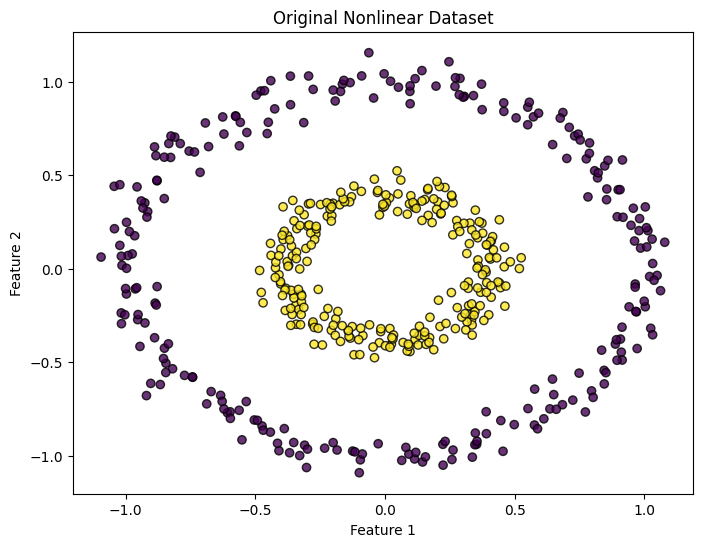

In [3]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="viridis",
    edgecolor="k",
    alpha=0.8
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original Nonlinear Dataset")

plt.show()

# 15. Feature Scaling

Feature scaling is important for Kernel PCA, especially when using distance-based kernels such as the RBF kernel.

The RBF kernel depends on the distance:

$$
||x_i-x_j||^2
$$

If one feature has a much larger scale than another feature, it can dominate the distance calculation.

Therefore, we standardize the features.

Standardization is:

$$
z =
\frac{x-\mu}{\sigma}
$$

where:

- $\mu$ is the mean
- $\sigma$ is the standard deviation

In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.70273073,  0.32422688],
       [-0.31202662,  1.83163878],
       [-0.69548478,  0.02998279],
       [-1.24825549, -1.22635567],
       [-1.53701552,  1.10249717]])

# 16. Standard PCA on Nonlinear Data

First, we apply ordinary PCA.

This gives us a baseline for comparison.

Because PCA is a linear method, it may not capture the circular structure effectively.

In [5]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

X_pca.shape

(500, 2)

## PCA Explained Variance

In [6]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal explained variance:")
print(pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.50023506 0.49976494]

Total explained variance:
1.0


## Visualize PCA

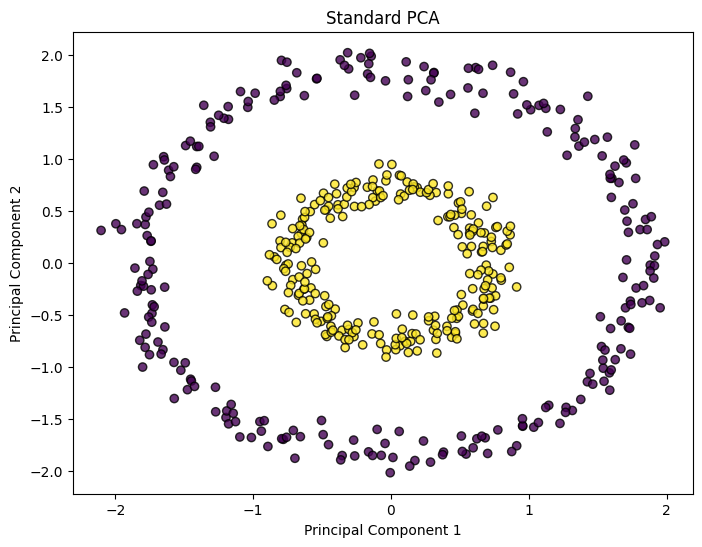

In [7]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="viridis",
    edgecolor="k",
    alpha=0.8
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Standard PCA")

plt.show()

# 17. Applying Kernel PCA

Now we apply Kernel PCA using the RBF kernel.

The RBF kernel is:

$$
K(x_i,x_j)
=
\exp
\left(
-\gamma ||x_i-x_j||^2
\right)
$$

The parameter $\gamma$ controls how quickly the similarity decreases as the distance between two samples increases.

A larger $\gamma$ means that the kernel focuses more strongly on nearby points.

A smaller $\gamma$ produces a smoother representation.

For this example, we will start with:

$$
\gamma = 15
$$

In [8]:
kpca = KernelPCA(
    n_components=2,
    kernel="rbf",
    gamma=15
)

X_kpca = kpca.fit_transform(X_scaled)

X_kpca.shape

(500, 2)

## Visualize Kernel PCA

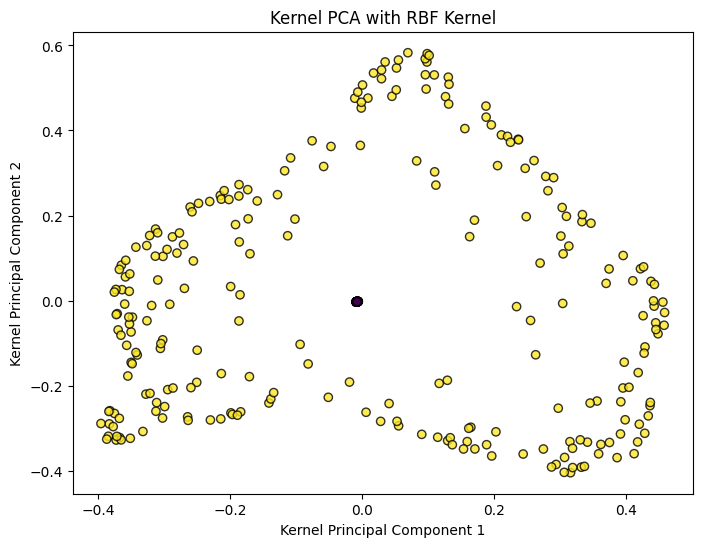

In [9]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_kpca[:, 0],
    X_kpca[:, 1],
    c=y,
    cmap="viridis",
    edgecolor="k",
    alpha=0.8
)

plt.xlabel("Kernel Principal Component 1")
plt.ylabel("Kernel Principal Component 2")
plt.title("Kernel PCA with RBF Kernel")

plt.show()

# 18. PCA vs Kernel PCA on Nonlinear Data

We can now compare the two methods.

### Standard PCA

PCA searches for linear directions of maximum variance.

Therefore, it may not capture the nonlinear circular structure effectively.

### Kernel PCA

Kernel PCA maps the data into an implicit feature space and performs PCA there.

The nonlinear structure can become more useful in the transformed space.

### Conceptual comparison

$$
\text{PCA}
:
X
\rightarrow
\text{Linear Projection}
$$

$$
\text{Kernel PCA}
:
X
\rightarrow
\phi(X)
\rightarrow
\text{Linear Projection}
$$

The important difference is the feature-space transformation.

# 19. Effect of the Gamma Parameter

For the RBF kernel:

$$
K(x_i,x_j)
=
\exp
\left(
-\gamma ||x_i-x_j||^2
\right)
$$

The parameter $\gamma$ controls the locality of the kernel.

### Small gamma

A small $\gamma$ creates a broader influence between samples.

This produces a smoother representation.

### Large gamma

A large $\gamma$ makes the kernel more sensitive to nearby points.

This can produce a more complex representation.

Therefore, $\gamma$ is an important hyperparameter.

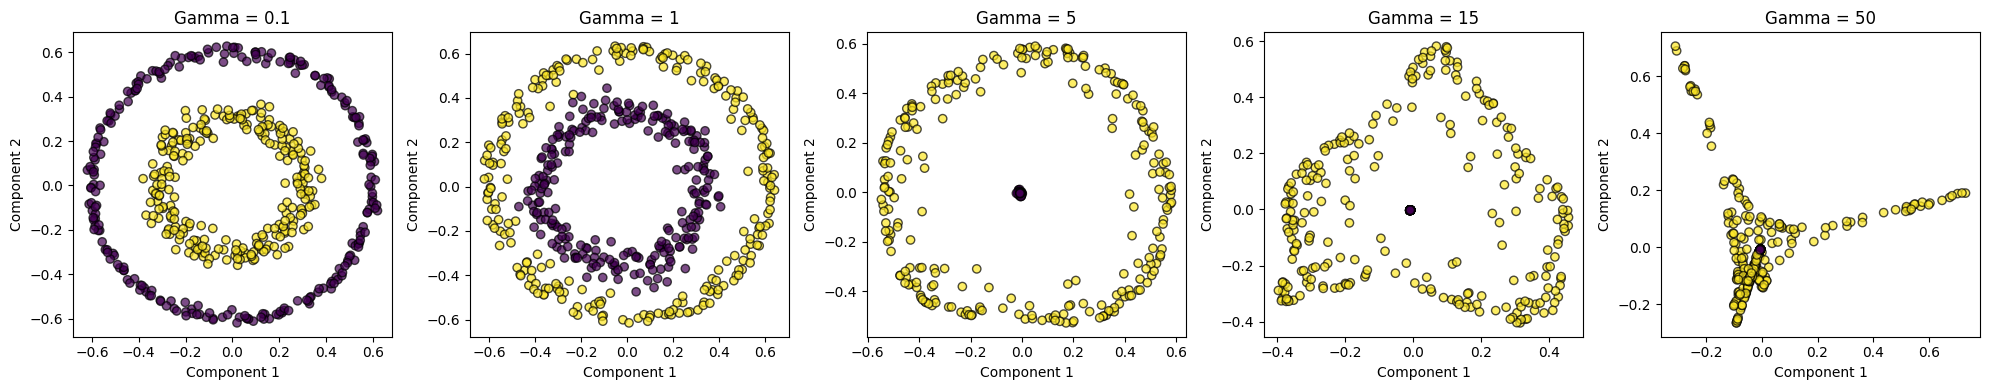

In [10]:
gamma_values = [0.1, 1, 5, 15, 50]

fig, axes = plt.subplots(
    1,
    len(gamma_values),
    figsize=(20, 4)
)

for ax, gamma in zip(axes, gamma_values):

    kpca = KernelPCA(
        n_components=2,
        kernel="rbf",
        gamma=gamma
    )

    X_transformed = kpca.fit_transform(X_scaled)

    ax.scatter(
        X_transformed[:, 0],
        X_transformed[:, 1],
        c=y,
        cmap="viridis",
        edgecolor="k",
        alpha=0.7
    )

    ax.set_title(f"Gamma = {gamma}")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

plt.tight_layout()
plt.show()

# 20. Kernel PCA with Polynomial Kernel

Kernel PCA can also use a polynomial kernel.

The polynomial kernel is:

$$
K(x_i,x_j)
=
(\gamma x_i^T x_j + c_0)^d
$$

The degree $d$ controls the complexity of the polynomial transformation.

For example:

$$
d=2
$$

represents a quadratic relationship.

We can test a polynomial kernel using scikit-learn.

In [11]:
kpca_poly = KernelPCA(
    n_components=2,
    kernel="poly",
    degree=3,
    gamma=1,
    coef0=1
)

X_kpca_poly = kpca_poly.fit_transform(X_scaled)

X_kpca_poly.shape

(500, 2)

## Visualize Polynomial Kernel PCA

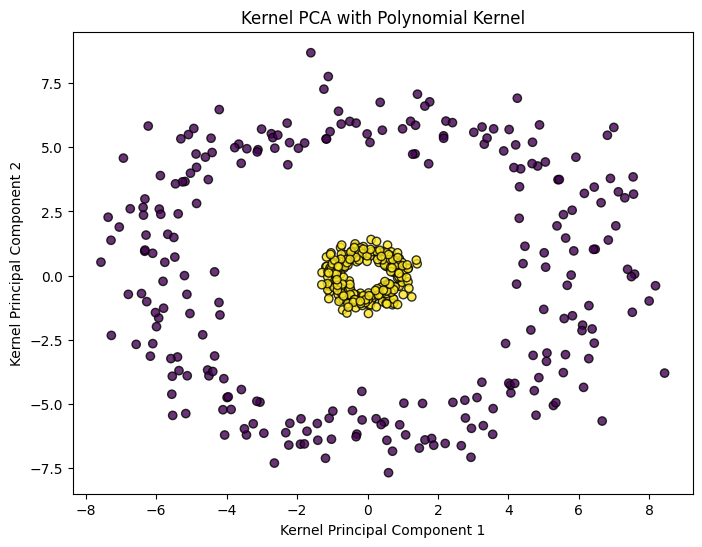

In [12]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_kpca_poly[:, 0],
    X_kpca_poly[:, 1],
    c=y,
    cmap="viridis",
    edgecolor="k",
    alpha=0.8
)

plt.xlabel("Kernel Principal Component 1")
plt.ylabel("Kernel Principal Component 2")
plt.title("Kernel PCA with Polynomial Kernel")

plt.show()

# 21. Kernel PCA with Linear Kernel

We can also use a linear kernel.

The linear kernel is:

$$
K(x_i,x_j)
=
x_i^T x_j
$$

This does not introduce a nonlinear transformation.

Therefore, linear Kernel PCA should behave similarly to standard PCA.

This is useful for understanding that the kernel determines the type of structure Kernel PCA can capture.

In [13]:
kpca_linear = KernelPCA(
    n_components=2,
    kernel="linear"
)

X_kpca_linear = kpca_linear.fit_transform(X_scaled)

X_kpca_linear.shape

(500, 2)

## Compare Linear Kernel with PCA

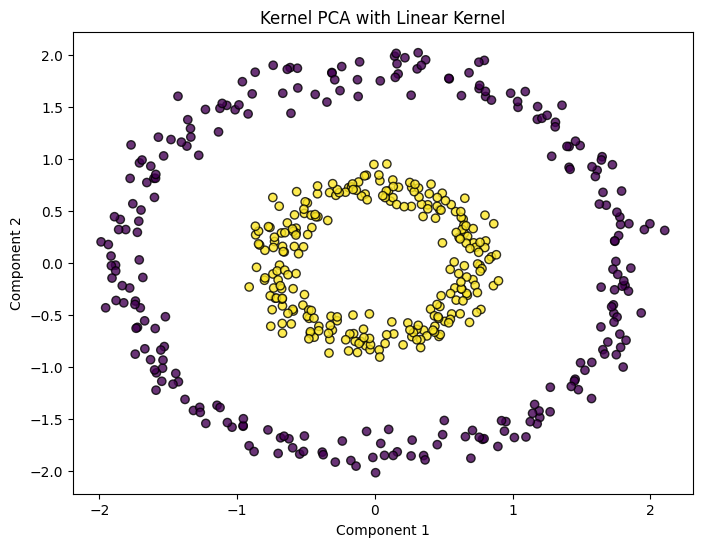

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_kpca_linear[:, 0],
    X_kpca_linear[:, 1],
    c=y,
    cmap="viridis",
    edgecolor="k",
    alpha=0.8
)

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("Kernel PCA with Linear Kernel")

plt.show()

# 22. Comparing Different Kernels

Kernel PCA can produce very different representations depending on the kernel.

### Linear kernel

Captures linear relationships.

### Polynomial kernel

Captures polynomial relationships.

### RBF kernel

Captures more general nonlinear relationships.

### Sigmoid kernel

Provides another nonlinear similarity function.

Therefore:

$$
\text{Kernel Choice}
\rightarrow
\text{Representation Quality}
$$

There is no universally best kernel.

The appropriate kernel depends on the structure of the dataset.

# 23. Choosing the Number of Components

Like PCA, Kernel PCA allows us to choose the number of dimensions in the transformed representation.

Suppose the original dataset has:

$$
d = 100
$$

features.

We might transform it into:

$$
k = 2
$$

or:

$$
k = 10
$$

dimensions.

Therefore:

$$
k < d
$$

is typically used for dimensionality reduction.

A smaller value of $k$ gives stronger compression.

A larger value of $k$ preserves more information but provides less dimensionality reduction.

Unlike standard PCA, explained variance interpretation is less straightforward in Kernel PCA, so component selection often requires validation based on the downstream task or visualization.

# 24. Kernel PCA as a Preprocessing Technique

Kernel PCA can be used before another machine learning algorithm.

For example:

$$
\text{Original Features}
\rightarrow
\text{Kernel PCA}
\rightarrow
\text{Classifier}
$$

The idea is to transform the original nonlinear feature space into a lower-dimensional representation.

This can potentially make a downstream model easier to train.

A typical workflow is:

$$
X
\rightarrow
\text{Scaling}
\rightarrow
\text{Kernel PCA}
\rightarrow
\text{Machine Learning Model}
$$

However, Kernel PCA should not automatically be used before every model.

Its usefulness should be evaluated using validation data.

# 25. Reconstruction in Kernel PCA

In ordinary PCA, we can approximately reconstruct the original data from the selected principal components.

For PCA:

$$
X \approx ZW^T
$$

Kernel PCA works in an implicit feature space, so reconstruction is more complicated.

The original samples are represented indirectly through kernel similarities.

Scikit-learn provides an approximate inverse transformation when:

$$
fit_inverse_transform=True
$$

This is called an approximate pre-image reconstruction.

It is important to remember that inverse transformation in Kernel PCA is generally not as straightforward as reconstruction in standard PCA.

## Inverse Transform Example

In [15]:
kpca_inverse = KernelPCA(
    n_components=2,
    kernel="rbf",
    gamma=15,
    fit_inverse_transform=True
)

X_kpca_inverse = kpca_inverse.fit_transform(X_scaled)

X_reconstructed = kpca_inverse.inverse_transform(
    X_kpca_inverse
)

X_reconstructed.shape

(500, 2)

## Reconstruction Visualization

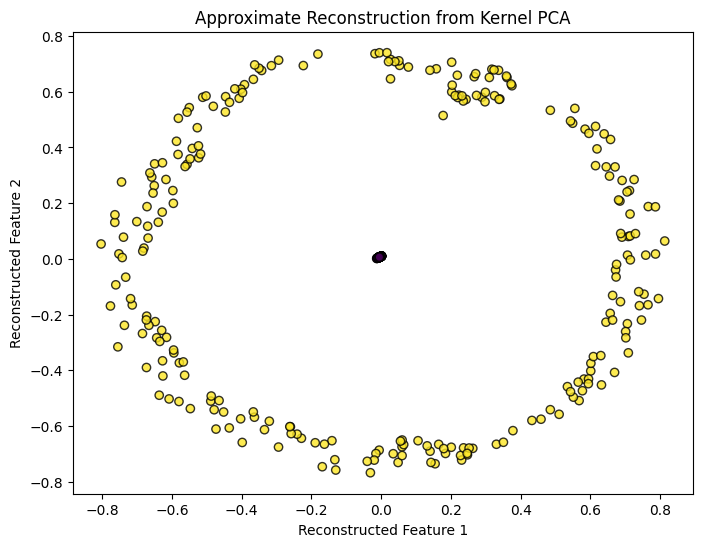

In [16]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_reconstructed[:, 0],
    X_reconstructed[:, 1],
    c=y,
    cmap="viridis",
    edgecolor="k",
    alpha=0.8
)

plt.xlabel("Reconstructed Feature 1")
plt.ylabel("Reconstructed Feature 2")
plt.title("Approximate Reconstruction from Kernel PCA")

plt.show()

# 26. Practical Kernel PCA Workflow

A practical Kernel PCA workflow usually looks like this:

### Step 1

Load the dataset.

### Step 2

Separate features from the target if necessary.

### Step 3

Split the data into training and testing sets when Kernel PCA is being used as part of a predictive pipeline.

### Step 4

Scale the features.

### Step 5

Choose a kernel.

### Step 6

Choose the kernel parameters.

### Step 7

Select the number of components.

### Step 8

Fit Kernel PCA using the training data.

### Step 9

Transform the training and testing data.

### Step 10

Train the downstream model.

### Step 11

Evaluate performance.

### Important rule

When Kernel PCA is part of a machine learning pipeline, fit the scaler and Kernel PCA only on the training data.

This prevents information from the test set from leaking into the training process.

# 27. Important Kernel PCA Hyperparameters

Some important Kernel PCA parameters are:

### n_components

Number of components to keep.

Example:

$$
k=2
$$

is useful for visualization.

---

### kernel

Specifies the kernel function.

Common options:

- `"linear"`
- `"poly"`
- `"rbf"`
- `"sigmoid"`

---

### gamma

Controls the influence of individual training samples for kernels such as RBF and polynomial kernels.

For the RBF kernel:

$$
K(x_i,x_j)
=
\exp
\left(
-\gamma ||x_i-x_j||^2
\right)
$$

---

### degree

Used by the polynomial kernel.

Example:

$$
d=3
$$

---

### coef0

Controls the independent term in polynomial and sigmoid kernels.

---

### fit_inverse_transform

Determines whether an approximate inverse transformation should be learned.

# 28. Computational Considerations

One of the biggest limitations of Kernel PCA is the kernel matrix.

For $n$ samples:

$$
K \in \mathbb{R}^{n \times n}
$$

Therefore, the number of kernel values grows approximately as:

$$
O(n^2)
$$

The eigendecomposition can also become expensive.

This means Kernel PCA is generally more suitable for datasets with a manageable number of samples.

### Important distinction

The computational challenge is primarily related to the number of samples:

$$
n
$$

rather than only the number of features:

$$
d
$$

Therefore, Kernel PCA can become expensive even when the original feature dimension is relatively small if the dataset contains a very large number of samples.

# 29. Kernel PCA vs PCA vs t-SNE

Kernel PCA is one of several dimensionality-reduction techniques.

| Method | Linear / Nonlinear | Main Purpose | Interpretability | Scalability |
|---|---|---|---|---|
| PCA | Linear | Dimensionality reduction | High | High |
| Kernel PCA | Nonlinear | Dimensionality reduction | Medium/Low | Lower |
| t-SNE | Nonlinear | Visualization | Low | Lower |
| UMAP | Nonlinear | Visualization / embedding | Low | Generally better than t-SNE |

### PCA

Best when the structure is approximately linear.

### Kernel PCA

Useful when nonlinear structure is important and the dataset size is manageable.

### t-SNE

Primarily designed for visualization and preserving local neighborhood structure.

### UMAP

Often used for visualization and nonlinear manifold learning with better scalability than traditional t-SNE in many settings.

These methods should not be treated as interchangeable.

# 30. Common Mistakes with Kernel PCA

### Mistake 1 — Not scaling the data

Distance-based kernels can be strongly affected by feature scale.

---

### Mistake 2 — Choosing gamma arbitrarily

The RBF parameter $\gamma$ can significantly change the resulting representation.

---

### Mistake 3 — Assuming Kernel PCA is always better than PCA

Kernel PCA is more flexible, but that does not mean it is always better.

If the data is approximately linear, standard PCA may be simpler and more effective.

---

### Mistake 4 — Using too many components

The purpose of dimensionality reduction is defeated if almost all dimensions are retained.

---

### Mistake 5 — Ignoring computational cost

The kernel matrix grows as:

$$
n \times n
$$

so large datasets can become expensive.

---

### Mistake 6 — Treating visualization as proof of model quality

A visually attractive two-dimensional embedding does not necessarily mean that the representation is useful for a predictive task.

# 31. When Kernel PCA Is a Good Choice

Kernel PCA is a strong candidate when:

$$
\text{Nonlinear Structure}
+
\text{Moderate Dataset Size}
+
\text{Need for Dimensionality Reduction}
$$

For example:

- Nonlinear pattern visualization
- Feature extraction
- Preprocessing
- Nonlinear manifold exploration
- Preparing data for downstream machine learning models

However, the method should be evaluated experimentally rather than selected only because it is nonlinear.

# 32. Complete Kernel PCA Example

Now we combine the major steps into a single workflow:

$$
\text{Generate Data}
\rightarrow
\text{Scale Data}
\rightarrow
\text{Kernel PCA}
\rightarrow
\text{Visualize Result}
$$

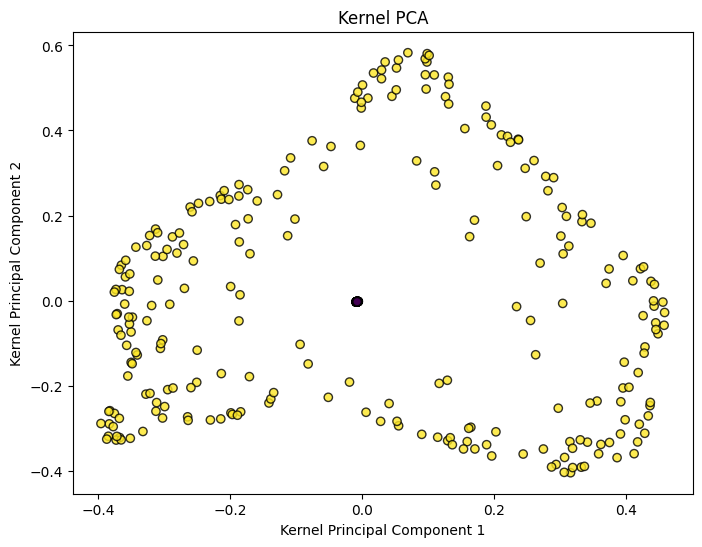

In [17]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import KernelPCA


# Generate nonlinear data
X, y = make_circles(
    n_samples=500,
    factor=0.4,
    noise=0.05,
    random_state=42
)


# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Apply Kernel PCA
kpca = KernelPCA(
    n_components=2,
    kernel="rbf",
    gamma=15
)

X_kpca = kpca.fit_transform(X_scaled)


# Visualize
plt.figure(figsize=(8, 6))

plt.scatter(
    X_kpca[:, 0],
    X_kpca[:, 1],
    c=y,
    cmap="viridis",
    edgecolor="k",
    alpha=0.8
)

plt.xlabel("Kernel Principal Component 1")
plt.ylabel("Kernel Principal Component 2")
plt.title("Kernel PCA")

plt.show()

# 33. Mathematical Summary

The most important equations in Kernel PCA are:

### Feature mapping

$$
x \rightarrow \phi(x)
$$

---

### Kernel function

$$
K(x_i,x_j)
=
\phi(x_i)^T\phi(x_j)
$$

---

### Kernel matrix

$$
K_{ij}=K(x_i,x_j)
$$

---

### Centering matrix

$$
H
=
I-\frac{1}{n}\mathbf{1}\mathbf{1}^T
$$

---

### Centered kernel matrix

$$
K_c=HKH
$$

---

### Eigenvalue problem

$$
K_c\alpha_k
=
\lambda_k\alpha_k
$$

---

### RBF kernel

$$
K(x_i,x_j)
=
\exp
\left(
-\gamma||x_i-x_j||^2
\right)
$$

---

### Projection

$$
z_k(x)
=
\sum_{i=1}^{n}
\alpha_{ik}K(x_i,x)
$$

These equations form the mathematical foundation of Kernel PCA.

# 34. Final Comparison: PCA vs Kernel PCA

| Property | PCA | Kernel PCA |
|---|---|---|
| Type | Linear | Nonlinear |
| Feature space | Original space | Implicit transformed space |
| Kernel required | No | Yes |
| Captures nonlinear patterns | No | Yes |
| Computational cost | Relatively low | Higher |
| Scalability | Good | Limited for very large datasets |
| Interpretability | Better | More difficult |
| Hyperparameters | Few | Kernel-dependent |
| Feature scaling | Important | Very important |
| Visualization | Good | Very good for nonlinear structures |
| Reconstruction | Straightforward | More difficult |
| Best use case | Linear structure | Nonlinear structure |

### Main takeaway

PCA asks:

$$
\text{"Which linear directions explain the most variance?"}
$$

Kernel PCA effectively asks:

$$
\text{"Can we transform the data into a feature space where useful nonlinear structure can be captured by PCA?"}
$$

# 35. Advantages and Disadvantages — Quick Revision

## Advantages

- Captures nonlinear structure
- Flexible kernel choices
- Useful for nonlinear dimensionality reduction
- Useful for visualization
- Uses the kernel trick
- Can be used as a preprocessing method

## Disadvantages

- Kernel matrix can be expensive
- Poor scalability for very large datasets
- Kernel selection matters
- Hyperparameter tuning may be necessary
- Less interpretable than standard PCA
- Reconstruction is more difficult
- Feature scaling is important

# 36. Final Summary

Kernel PCA is a nonlinear extension of Principal Component Analysis.

The central idea is:

$$
X
\rightarrow
\phi(X)
\rightarrow
\text{PCA}
$$

Instead of explicitly computing the potentially high-dimensional feature mapping $\phi(X)$, Kernel PCA uses a kernel function:

$$
K(x_i,x_j)
=
\phi(x_i)^T\phi(x_j)
$$

The main steps are:

1. Scale the data.
2. Choose a kernel.
3. Construct the kernel matrix.
4. Center the kernel matrix.
5. Perform eigendecomposition.
6. Select the principal components.
7. Transform the data.

The most commonly used nonlinear kernel is the RBF kernel:

$$
K(x_i,x_j)
=
\exp
\left(
-\gamma||x_i-x_j||^2
\right)
$$

The most important practical considerations are:

- Kernel choice
- Gamma selection
- Number of components
- Feature scaling
- Dataset size
- Computational cost

### Final intuition

Standard PCA:

$$
\boxed{
\text{Linear structure}
\rightarrow
\text{PCA}
}
$$

Kernel PCA:

$$
\boxed{
\text{Nonlinear structure}
\rightarrow
\text{Kernel transformation}
\rightarrow
\text{PCA}
}
$$

Kernel PCA is therefore a powerful method when ordinary PCA cannot adequately capture the structure of the data.